In [1]:
# import scvelo as scv
from multiprocessing import Pool

import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import rcParams

In [2]:
import mudata as mu

In [3]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp


## 2 · Data Loading

Load mudata

In [4]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

In [5]:
mdata

MuData object with n_obs × n_vars = 72592 × 17590
  3 modalities
    gex:	72592 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	56305 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	56305 x 0
      obs:	'sample_id'
      obsm:	'airr'

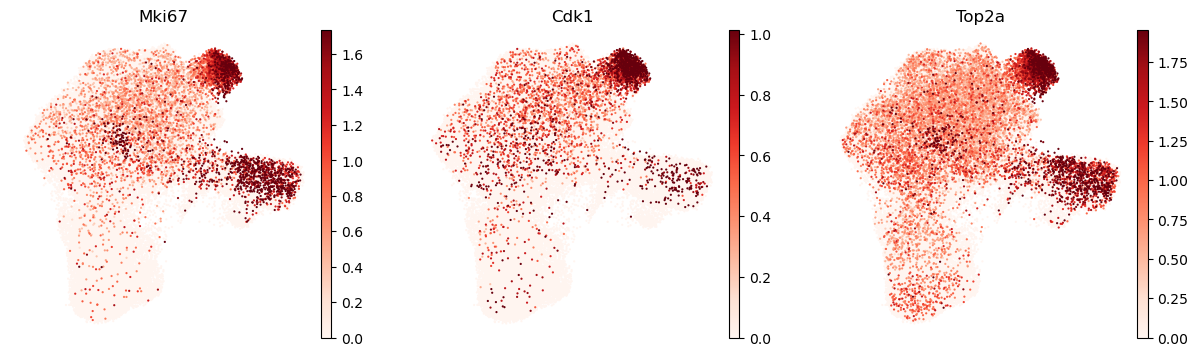

In [16]:
sc.pl.umap(mdata["gex"], color = ["Mki67","Cdk1","Top2a"], vmax="p99", cmap="Reds", frameon=False, size=10)

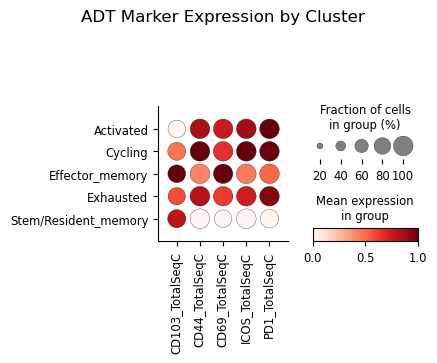

In [13]:
import scanpy as sc

# 1. Define the ADT markers you want to plot
adt_markers = [
    "CD103_TotalSeqC",
    "CD44_TotalSeqC",
    "CD69_TotalSeqC",
    "ICOS_TotalSeqC",
    "PD1_TotalSeqC",
]

# 2. Transfer your cluster annotations from GEX (or MuData) to ADT
# Replace 'leiden' or 'cell_annotation' with your exact cluster column name

# 3. Plot the ADT dotplot directly using Scanpy on the ADT modality
sc.pl.dotplot(
    mdata["adt"],
    var_names=adt_markers,
    groupby="clusters",
    cmap="Reds",
    standard_scale="var",  # Scales expression 0 to 1 per marker for better contrast
    title="ADT Marker Expression by Cluster",
)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

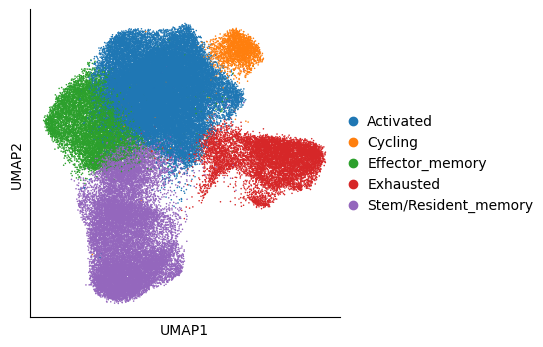

In [7]:
sc.pl.umap(
    mdata["gex"],
    color=["cell_annotation_05"],
    frameon=True,
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [7]:
mdata_srm = mdata[mdata["gex"].obs["cell_annotation_05"].isin(["Stem/Resident_memory"])]

In [8]:
mdata_srm

View of MuData object with n_obs × n_vars = 18779 × 17590
  3 modalities
    gex:	18779 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	16427 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	16427 x 0
      obs:	'sample_id'
      obsm:	'airr'

The title list is shorter than the number of panels. Using 'color' value instead for some plots.
The title list is shorter than the number of panels. Using 'color' value instead for some plots.


[<Axes: xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Itgae'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Sell'}, xlabel='UMAP1', ylabel='UMAP2'>]

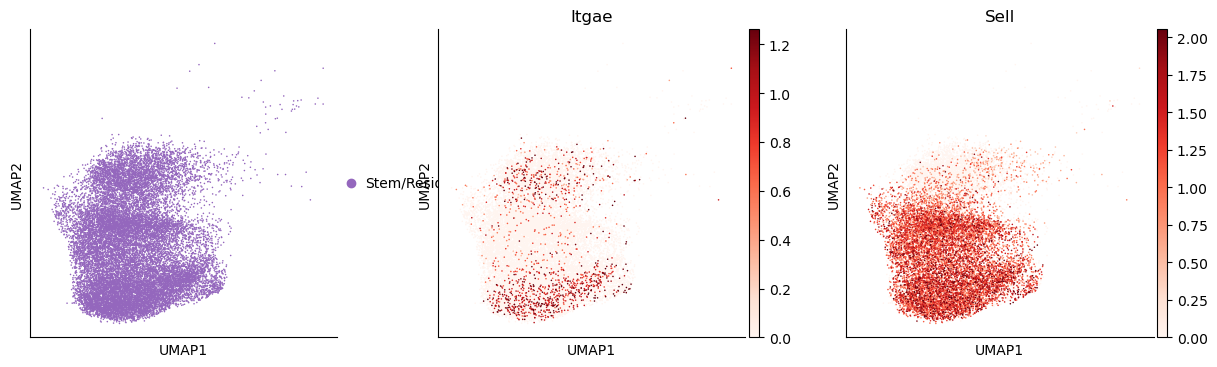

In [9]:
sc.pl.umap(
    mdata_srm["gex"],
    color=["cell_annotation_05","Itgae","Sell"],
    frameon=True, vmax= "p99",cmap="Reds",
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [10]:
sc.pp.neighbors(mdata_srm["gex"])

I0000 00:00:1785831589.295285 2651270 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785831589.847446 2651270 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785831594.568484 2651270 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [11]:
sc.tl.umap(mdata_srm["gex"])

In [19]:
sc.tl.leiden(mdata_srm["gex"], flavor="igraph", n_iterations=2, resolution=0.3, key_added="leiden03")

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

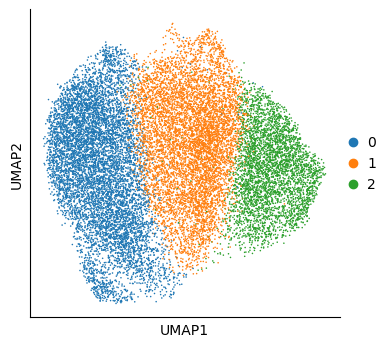

In [20]:
sc.pl.umap(
    mdata_srm["gex"],
    color=["leiden03"],
    frameon=True, vmax= "p99",cmap="Reds",
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

The title list is shorter than the number of panels. Using 'color' value instead for some plots.
The title list is shorter than the number of panels. Using 'color' value instead for some plots.


[<Axes: xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Itgae'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'Sell'}, xlabel='UMAP1', ylabel='UMAP2'>]

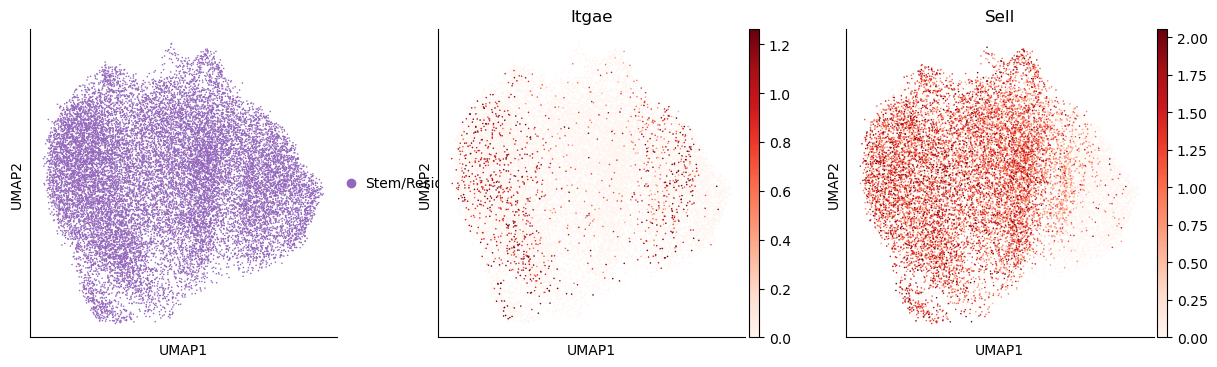

In [21]:
sc.pl.umap(
    mdata_srm["gex"],
    color=["cell_annotation_05","Itgae","Sell"],
    frameon=True, vmax= "p99",cmap="Reds",
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [22]:
mdata_srm

View of MuData object with n_obs × n_vars = 18779 × 17590
  3 modalities
    gex:	18779 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'leiden03'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap', 'leiden03', 'leiden03_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	16427 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	16427 x 0
      obs:	'sample_id'
      obsm:	'airr'

In [23]:
mdata_srm["adt"].var

""
1Ab_TotalSeqC
2Ab_TotalSeqC
3Ab_TotalSeqC
4Ab_TotalSeqC
CD103_TotalSeqC
CD44_TotalSeqC
CD69_TotalSeqC
ICOS_TotalSeqC
PD1_TotalSeqC


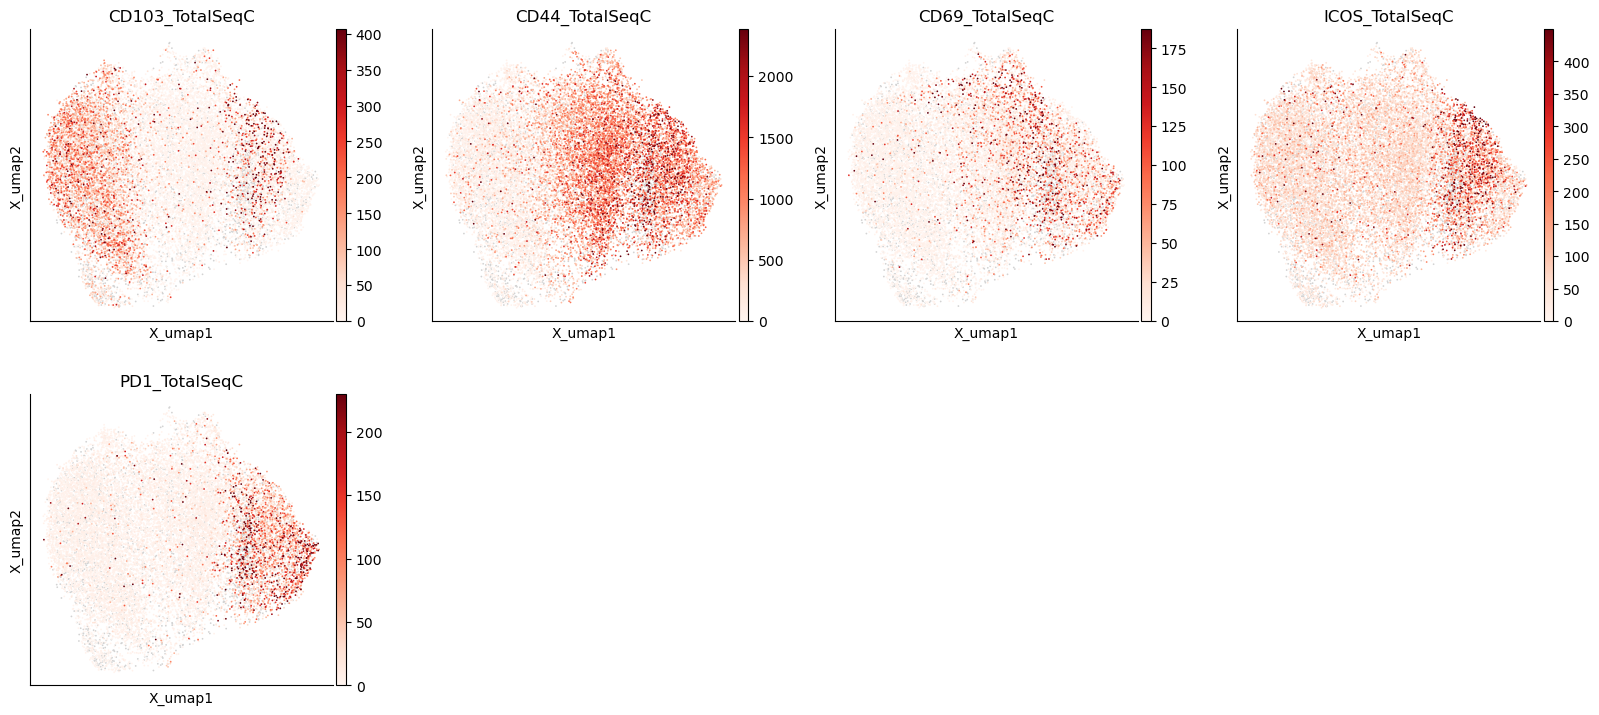

In [24]:
import muon as mu

# Plot specific ADT markers on the GEX UMAP
mu.pl.embedding(
    mdata_srm,
    basis="gex:X_umap",  # Use UMAP coordinates from the GEX modality
    color=["adt:CD103_TotalSeqC", "adt:CD44_TotalSeqC","adt:CD69_TotalSeqC","adt:ICOS_TotalSeqC","adt:PD1_TotalSeqC"],  # Replace with exact antibody names in mdata['adt'].var_names
    color_map="Reds", vmax="p99"
)

/tmp/ipykernel_2651270/2542560553.py:14: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mdata_srm["adt"].obs["clusters"] = mdata_srm["gex"].obs["leiden03"]


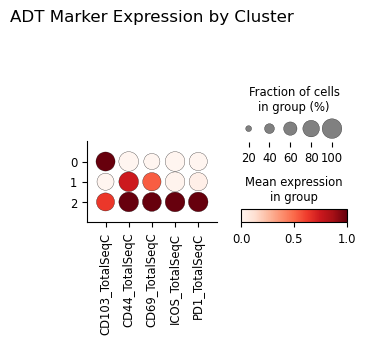

In [25]:
import scanpy as sc

# 1. Define the ADT markers you want to plot
adt_markers = [
    "CD103_TotalSeqC",
    "CD44_TotalSeqC",
    "CD69_TotalSeqC",
    "ICOS_TotalSeqC",
    "PD1_TotalSeqC",
]

# 2. Transfer your cluster annotations from GEX (or MuData) to ADT
# Replace 'leiden' or 'cell_annotation' with your exact cluster column name
mdata_srm["adt"].obs["clusters"] = mdata_srm["gex"].obs["leiden03"]

# 3. Plot the ADT dotplot directly using Scanpy on the ADT modality
sc.pl.dotplot(
    mdata_srm["adt"],
    var_names=adt_markers,
    groupby="clusters",
    cmap="Reds",
    standard_scale="var",  # Scales expression 0 to 1 per marker for better contrast
    title="ADT Marker Expression by Cluster",
)

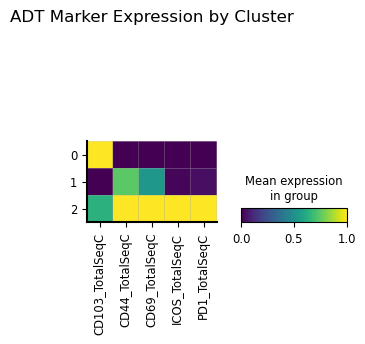

In [26]:
import scanpy as sc

# 1. Define the ADT markers you want to plot
adt_markers = [
    "CD103_TotalSeqC",
    "CD44_TotalSeqC",
    "CD69_TotalSeqC",
    "ICOS_TotalSeqC",
    "PD1_TotalSeqC",
]

# 2. Transfer your cluster annotations from GEX (or MuData) to ADT
# Replace 'leiden' or 'cell_annotation' with your exact cluster column name
mdata_srm["adt"].obs["clusters"] = mdata_srm["gex"].obs["leiden03"]

# 3. Plot the ADT dotplot directly using Scanpy on the ADT modality
sc.pl.matrixplot(
    mdata_srm["adt"],
    var_names=adt_markers,
    groupby="clusters",
    cmap="viridis",
    standard_scale="var",  # Scales expression 0 to 1 per marker for better contrast
    title="ADT Marker Expression by Cluster",
)

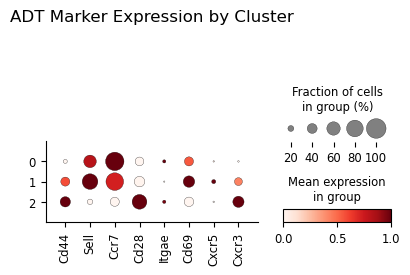

In [27]:
sc.pl.dotplot(
    mdata_srm["gex"],
    var_names=["Cd44","Sell","Ccr7","Cd28","Itgae","Cd69","Cxcr5","Cxcr3"],#"Lef1","Foxp1","Pdcd1","Cxcr3","Eomes","Cx3cr1","Klrg1",],
    groupby="leiden03",
    cmap="Reds",
    standard_scale="var",  # Scales expression 0 to 1 per marker for better contrast
    title="ADT Marker Expression by Cluster",
)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

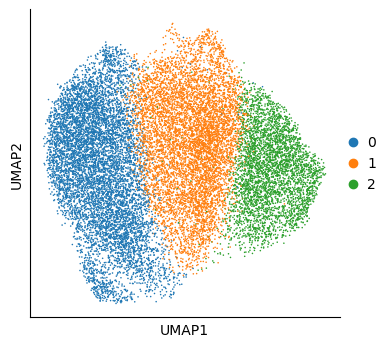

In [28]:
sc.pl.umap(
    mdata_srm["gex"],
    color=["leiden03"],
    frameon=True, vmax= "p99",cmap="Reds",
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

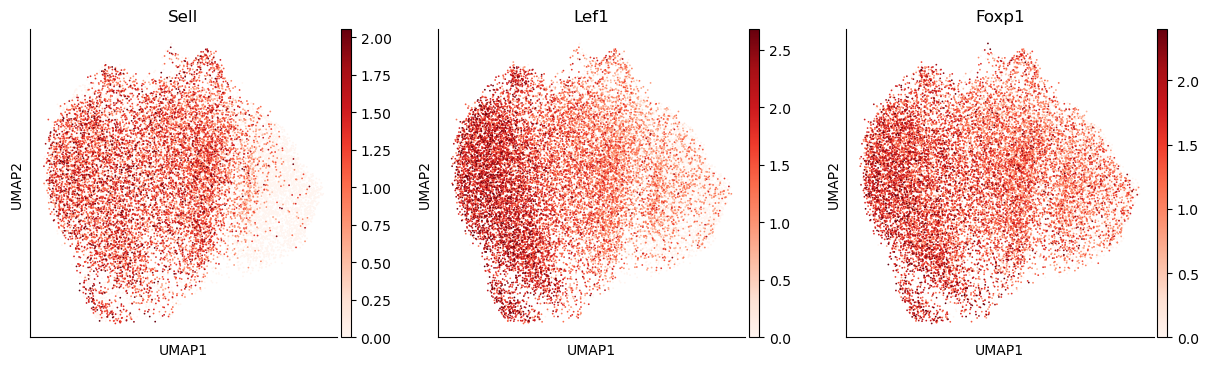

In [29]:
import muon as mu

# Plot specific ADT markers on the GEX UMAP
sc.pl.umap(
    mdata_srm["gex"],
    color=["Sell","Lef1","Foxp1"],  # Replace with exact antibody names in mdata['adt'].var_names
    color_map="Reds", vmax="p99"
)

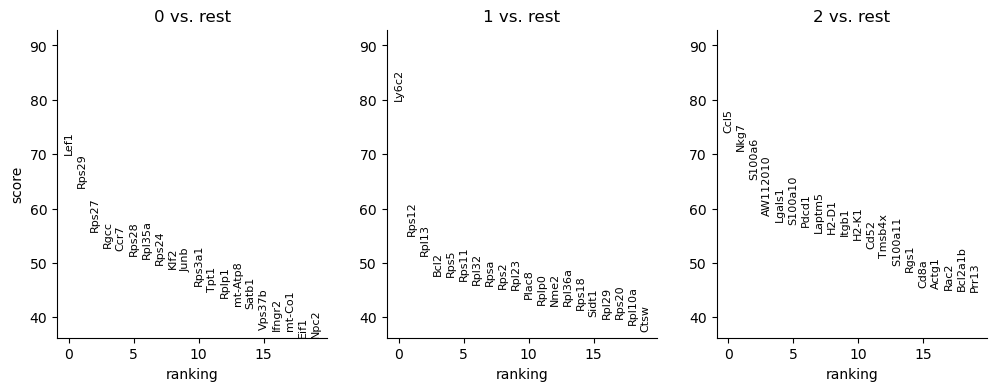

In [30]:
sc.tl.rank_genes_groups(mdata_srm["gex"], "leiden03", method="wilcoxon")
# to visualize the results
sc.pl.rank_genes_groups(mdata_srm["gex"])

In [31]:
markers_df = sc.get.rank_genes_groups_df(mdata_srm["gex"], group=None)

# View top rows
markers_df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Lef1,70.021957,1.795246,0.0,0.0
1,0,Rps29,63.949940,0.692628,0.0,0.0
2,0,Rps27,55.769329,0.492597,0.0,0.0
3,0,Rgcc,52.947063,2.311050,0.0,0.0
4,0,Ccr7,52.331291,1.386145,0.0,0.0


In [32]:
result = mdata_srm["gex"].uns["rank_genes_groups"]
top_genes = pd.DataFrame(result["names"]).head(20)

# top_genes now has columns: '0s', '1', '2' containing top 20 gene names
print(top_genes)

          0       1         2
0      Lef1   Ly6c2      Ccl5
1     Rps29   Rps12      Nkg7
2     Rps27   Rpl13    S100a6
3      Rgcc    Bcl2  AW112010
4      Ccr7    Rps5    Lgals1
5     Rps28   Rps11   S100a10
6    Rpl35a   Rpl32     Pdcd1
7     Rps24    Rpsa    Laptm5
8      Klf2    Rps2     H2-D1
9      Junb   Rpl23     Itgb1
10   Rps3a1   Plac8     H2-K1
11     Tpt1   Rplp0      Cd52
12    Rplp1    Nme2    Tmsb4x
13  mt-Atp8  Rpl36a   S100a11
14    Satb1   Rps18      Rgs1
15   Vps37b   Sidt1      Cd8a
16   Ifngr2   Rpl29     Actg1
17   mt-Co1   Rps20      Rac2
18     Eif1  Rpl10a   Bcl2a1b
19     Npc2    Ctsw     Prr13


## 3 · Pseudobulk for DGSEA

Running it on mdata_without_cycling for DGSEA we want to avoid the cycling genes that could be misleading

In [35]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import scanpy as sc
import decoupler as dc

# Define base output directory
base_output_dir = "/data/scratch/kvalem/projects/2021/honda_microbial_metabolites_2021/20_scripts/40_single-cell-sorted-cd8/40_gex_surface_prot/28012026/run_gsea/tables/extra_separate_strem_resident"
os.makedirs(base_output_dir, exist_ok=True)

# Get all unique clusters in leiden02 (sorted)
clusters = sorted(mdata_srm["gex"].obs["leiden03"].unique())

for cluster_id in clusters:
    print(f"\n==========================================")
    print(f"  Processing Cluster: {cluster_id}")
    print(f"==========================================")

    # 1. Subset the AnnData ('gex') directly to avoid MuData alignment issues
    gex_adata = mdata_srm["gex"]
    adata_sub = gex_adata[gex_adata.obs["leiden03"] == cluster_id].copy()

    # Create cluster-specific output directory
    cluster_dir = os.path.join(base_output_dir, f"cluster_{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)

    # 2. Perform Pseudobulk on the cluster subset
    pdata = dc.pp.pseudobulk(
        adata=adata_sub,
        sample_col="sample_id",
        groups_col=None,  # Aggregate counts across samples for this cluster
        mode="sum",
        empty=False,
        layer="counts",
    )

    # 3. Perform PCA (optional)
    sc.tl.pca(pdata)

    # 4. Filter genes (>=10 counts in at least 2 samples)
    counts = pdata.X
    if not isinstance(counts, np.ndarray):
        counts = counts.toarray()

    gene_filter = (counts >= 10).sum(axis=0) >= 2
    pdata_filtered = pdata[:, gene_filter].copy()

    print(f"Cluster {cluster_id} - Genes before filtering: {pdata.shape[1]}")
    print(f"Cluster {cluster_id} - Genes after filtering: {pdata_filtered.shape[1]}")

    # 5. Build and save Samplesheet
    samplesheet = pdata_filtered.obs.copy()
    samplesheet.insert(0, "sample", pdata_filtered.obs_names)

    samplesheet_path = os.path.join(cluster_dir, "samplesheet.csv")
    samplesheet.to_csv(samplesheet_path, index=False)
    print(f"Saved: {samplesheet_path}")

    # 6. Build and save Counts Matrix
    X = pdata_filtered.X
    if sparse.issparse(X):
        counts_array = X.toarray()
    else:
        counts_array = np.asarray(X)

    # Genes as rows, samples as columns
    counts_df = pd.DataFrame(
        counts_array.T,
        index=pdata_filtered.var_names,  # gene_name
        columns=pdata_filtered.obs_names,
    )

    gene_id = pdata_filtered.var["gene_ids"].values  # Gene IDs
    gene_name = pdata_filtered.var_names.values      # Gene symbols

    # Insert metadata columns
    counts_df.insert(0, "gene_name", gene_name)
    counts_df.insert(0, "gene_id", gene_id)

    # Round and format integer counts
    counts_df.iloc[:, 2:] = counts_df.iloc[:, 2:].round().astype(int)

    # Clean column names
    counts_df.columns = [
        col.replace("_all", "") if col not in ["gene_id", "gene_name"] else col
        for col in counts_df.columns
    ]

    counts_matrix_path = os.path.join(cluster_dir, "counts_matrix.tsv")
    counts_df.to_csv(counts_matrix_path, sep="\t", index=False)
    print(f"Saved: {counts_matrix_path}")


  Processing Cluster: 0
Cluster 0 - Genes before filtering: 17581
Cluster 0 - Genes after filtering: 10404
Saved: /data/scratch/kvalem/projects/2021/honda_microbial_metabolites_2021/20_scripts/40_single-cell-sorted-cd8/40_gex_surface_prot/28012026/run_gsea/tables/extra_separate_strem_resident/cluster_0/samplesheet.csv
Saved: /data/scratch/kvalem/projects/2021/honda_microbial_metabolites_2021/20_scripts/40_single-cell-sorted-cd8/40_gex_surface_prot/28012026/run_gsea/tables/extra_separate_strem_resident/cluster_0/counts_matrix.tsv

  Processing Cluster: 1
Cluster 1 - Genes before filtering: 17581
Cluster 1 - Genes after filtering: 10541
Saved: /data/scratch/kvalem/projects/2021/honda_microbial_metabolites_2021/20_scripts/40_single-cell-sorted-cd8/40_gex_surface_prot/28012026/run_gsea/tables/extra_separate_strem_resident/cluster_1/samplesheet.csv
Saved: /data/scratch/kvalem/projects/2021/honda_microbial_metabolites_2021/20_scripts/40_single-cell-sorted-cd8/40_gex_surface_prot/28012026/ru